# Réseaux de co-occurrences de personnages dans l'Évangile de Marc

Ce notebook génère des graphes de réseaux (NetworkX) modélisant les interactions entre les personnages de l'Évangile de Marc, chapitre par chapitre.

### Note méthodologique : `odyCy` (spaCy) vs `Text-Fabric` pour l'analyse de réseaux

La construction d'un graphe de co-occurrences nécessite de définir une **fenêtre d'interaction** : à quelle distance deux personnages doivent-ils apparaître pour être considérés comme "connectés" ou "en interaction" ?

1. **L'approche `odyCy` (Modèles NLP par flux) :**
   Les pipelines comme spaCy analysent le texte comme un flux continu (`Doc`). Bien qu'ils identifient efficacement les entités nommées (noms propres) via l'inférence par apprentissage automatique, ils ne possèdent pas nativement la structure hiérarchique du texte biblique. Définir une fenêtre sémantique exacte comme "le verset" ou "la phrase" nécessiterait un pré-découpage complexe du texte brut par expressions régulières *avant* de le soumettre au modèle.

2. **L'approche `Text-Fabric` (Base de données structurelle pré-annotée) :**
   Text-Fabric (utilisé avec le dataset N1904) exploite une base de données où l'architecture même du texte (`book`, `chapter`, `verse`, `sentence`, `clause`) est encodée sous forme de nœuds. Les lemmes et les natures grammaticales y sont validés par des spécialistes humains, garantissant une précision maximale.

**Le choix de la fenêtre narrative : La Phrase (`sentence`) plutôt que le Verset (`verse`)**
Historiquement, les versets sont un découpage éditorial tardif (Robert Estienne, 1551) qui scinde parfois artificiellement l'interaction entre deux personnages ou regroupe des actions disjointes. La **phrase syntaxique** (`sentence`), accessible instantanément via Text-Fabric, représente une unité d'action narrative beaucoup plus fine et pertinente : si deux personnages partagent la même phrase, ils participent généralement à la même action (sujet/objet d'un même verbe). C'est donc cette fenêtre que nous privilégions exclusivement ici.


In [1]:
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt
import itertools
import unicodedata

# Load Text-Fabric and the N1904 Greek New Testament dataset
from tf.app import use
A = use('CenterBLC/N1904', hoist=globals(), silent='deep')


Display is setup for viewtype [syntax-view](https://github.com/saulocantanhede/tfgreek2/blob/main/docs/syntax-view.md#start)

See [here](https://github.com/saulocantanhede/tfgreek2/blob/main/docs/viewtypes.md#start) for more information on viewtypes

In [2]:
# Helper to normalize Greek accents
def remove_accents(text):
    text = text.replace("(", "").replace(")", "").replace("2", "")
    return ''.join(c for c in unicodedata.normalize('NFD', text) if unicodedata.category(c) != 'Mn').lower()

# Load STEPBible Dictionary to translate Greek names to English
lexicon_path = "STEPBible-Data/Lexicons/TBESG - Translators Brief lexicon of Extended Strongs for Greek - STEPBible.org CC BY.txt"
greek_to_english = {}

with open(lexicon_path, "r", encoding="utf-8") as f:
    for line in f:
        if line.startswith("G") and "\t" in line:
            parts = line.split("\t")
            if len(parts) >= 7:
                greek_words = parts[3].strip().split(",")
                english_gloss = parts[6].strip()
                for gw in greek_words:
                    clean_gw = remove_accents(gw.strip())
                    if clean_gw not in greek_to_english:
                        greek_to_english[clean_gw] = english_gloss

# Handle specific name translations
greek_to_english["βηθσαιδαν"] = "Bethsaida"
greek_to_english["ιεροσολυμων"] = "Jerusalem"
greek_to_english["ιησους"] = "Jesus"
greek_to_english["χριστος"] = "Jesus" # Merge Christ into Jesus
greek_to_english["μαριαμ"] = "Mary"
greek_to_english["κυρηναιος"] = "Cyrene"
greek_to_english["αριμαθαια"] = "Arimathea"
greek_to_english["ισκαριωθ"] = "Iscariot"
greek_to_english["ισκαριωτης"] = "Iscariot"
greek_to_english["γεθσημανι"] = "Gethsemane"
greek_to_english["ιωσης"] = "Joses"


# We want only People, so we exclude places and groups
EXCLUDED_ENTITIES = {
    "Jerusalem", "Galilee", "Judea", "Capernaum", "Arimathea", "Cyrene", "Magdalene", "Iscariot", "Golgotha", "Israel", "Jew", "Galilean", "Gethsemane", "Alexander", "Rufus", "Bethsaida", "Nazareth", 
    "Tyre", "Sidon", "Decapolis", "Jordan", "Gennesaret", "Pharisee", 
    "Sadducee", "Herodian", "Sodom", "Gomorrah", "Idumea", "Jericho", 
    "Bethphage", "Bethany", "Olives", "Egypt", "Syrophoenician", "Dalmanutha",
    "Sabbath", "Passover", "Satan", "Devil", "Lord", "God", "Holy Spirit"
}

def is_person(english_name):
    # Ignore group names or places based on our exclusion set
    if english_name in EXCLUDED_ENTITIES:
        return False
    if "Pharisee" in english_name or "Sadducee" in english_name or "Herodian" in english_name:
        return False
    return True


In [3]:
def extract_characters(node_list):
    """
    Given a list of word nodes (from a sentence), 
    return a set of unique character names in English, handling disambiguations.
    """
    characters = set()
    words_list = list(node_list)
    
    sentence_english_names = []
    for w in words_list:
        lemma = F.lemma.v(w)
        if lemma and lemma[0].isupper():
            norm_name = remove_accents(lemma)
            en_name = greek_to_english.get(norm_name, lemma).split(",")[0].strip()
            sentence_english_names.append(en_name)
            
    for i, w in enumerate(words_list):
        lemma = F.lemma.v(w)
        if lemma and lemma[0].isupper():
            norm_name = remove_accents(lemma)
            english_name = greek_to_english.get(norm_name, lemma).split(",")[0].strip()
            
            # --- DISAMBIGUATION RULES ---
            
            # 1. Johns
            if english_name == "John":
                john_type = "John the Baptist" 
                start_idx = max(0, i - 15)
                end_idx = min(len(words_list), i + 15)
                context_words = words_list[start_idx:end_idx]
                for cw in context_words:
                    clemma = remove_accents(F.lemma.v(cw))
                    if clemma in ['ζεβεδαιος', 'ιακωβος']:
                        john_type = "John (son of Zebedee)"
                        break
                english_name = john_type
                
            # 2. Marys
            elif english_name == "Mary":
                if "Magdalene" in sentence_english_names:
                    english_name = "Mary Magdalene"
                elif "James" in sentence_english_names or "Joses" in sentence_english_names or "Joseph" in sentence_english_names or "Salome" in sentence_english_names:
                    english_name = "Mary (mother of James)"
                else:
                    english_name = "Mary"
                    
            # 3. Josephs / Joses
            elif english_name == "Joseph" or english_name == "Joses":
                if norm_name == "ιωσης":
                    english_name = "Joses (brother of James)"
                elif norm_name == "ιωσηφ":
                    if "Arimathea" in sentence_english_names:
                        english_name = "Joseph of Arimathea"
                    else:
                        # By default in passion narrative, Joseph alone is Arimathea
                        english_name = "Joseph of Arimathea"
                
            # 4. Judas
            elif english_name == "Judas":
                english_name = "Judas Iscariot"
                    
            # 5. Simons
            elif english_name == "Simon":
                if "Cyrene" in sentence_english_names:
                    english_name = "Simon of Cyrene"
                elif "Peter" in sentence_english_names:
                    english_name = "Peter"
                elif any("λεπρου" in remove_accents(F.lemma.v(cw)) for cw in words_list):
                    english_name = "Simon the Leper"
                else:
                    english_name = "Simon"
            
            # Check if it should be excluded
            valid_disambiguated = [
                "John the Baptist", "John (son of Zebedee)", "Mary Magdalene", 
                "Mary (mother of James)", "Joseph of Arimathea", "Judas Iscariot", 
                "Simon of Cyrene", "Joses (brother of James)", "Simon the Leper"
            ]
            
            if english_name in valid_disambiguated or is_person(english_name):
                characters.add(english_name)
                
    return characters

def build_chapter_graph(chapter_node):
    G = nx.Graph()
    windows = L.d(chapter_node, otype="sentence")
    for window in windows:
        words = L.d(window, otype="word")
        characters = extract_characters(words)
        for char in characters:
            if not G.has_node(char):
                G.add_node(char, count=0)
            G.nodes[char]['count'] += 1
        for char1, char2 in itertools.combinations(characters, 2):
            if G.has_edge(char1, char2):
                G[char1][char2]['weight'] += 1
            else:
                G.add_edge(char1, char2, weight=1)
    return G


In [4]:
# Focus on the Gospel of Mark
mark_node = T.nodeFromSection(('Mark',))
chapters = L.d(mark_node, otype='chapter')

# Let's combine graphs for chapters 14 and 15 (The Passion)
G_combined = nx.Graph()

for chap_node in chapters[13:15]: # Chapters 14-15 (0-indexed array)
    chap_graph = build_chapter_graph(chap_node)
    
    # Merge chap_graph into G_combined
    for n, data in chap_graph.nodes(data=True):
        if G_combined.has_node(n):
            G_combined.nodes[n]['count'] += data['count']
        else:
            G_combined.add_node(n, count=data['count'])
            
    for u, v, data in chap_graph.edges(data=True):
        if G_combined.has_edge(u, v):
            G_combined[u][v]['weight'] += data['weight']
        else:
            G_combined.add_edge(u, v, weight=data['weight'])


# Manual correction: Connect Simon of Cyrene to Jesus. 
# In Mark 15:21, Simon is compelled to carry Jesus' cross, but Jesus is referenced by a pronoun,
# so the sentence-level proper noun extraction misses the direct connection.
if G_combined.has_node("Simon of Cyrene") and G_combined.has_node("Jesus"):
    if G_combined.has_edge("Simon of Cyrene", "Jesus"):
        G_combined["Simon of Cyrene"]["Jesus"]['weight'] += 1
    else:
        G_combined.add_edge("Simon of Cyrene", "Jesus", weight=1)

print(f"Chapters 14-15 (Passion) - Combined Sentence Graph: {G_combined.number_of_nodes()} nodes, {G_combined.number_of_edges()} edges")


Chapters 14-15 (Passion) - Combined Sentence Graph: 14 nodes, 16 edges


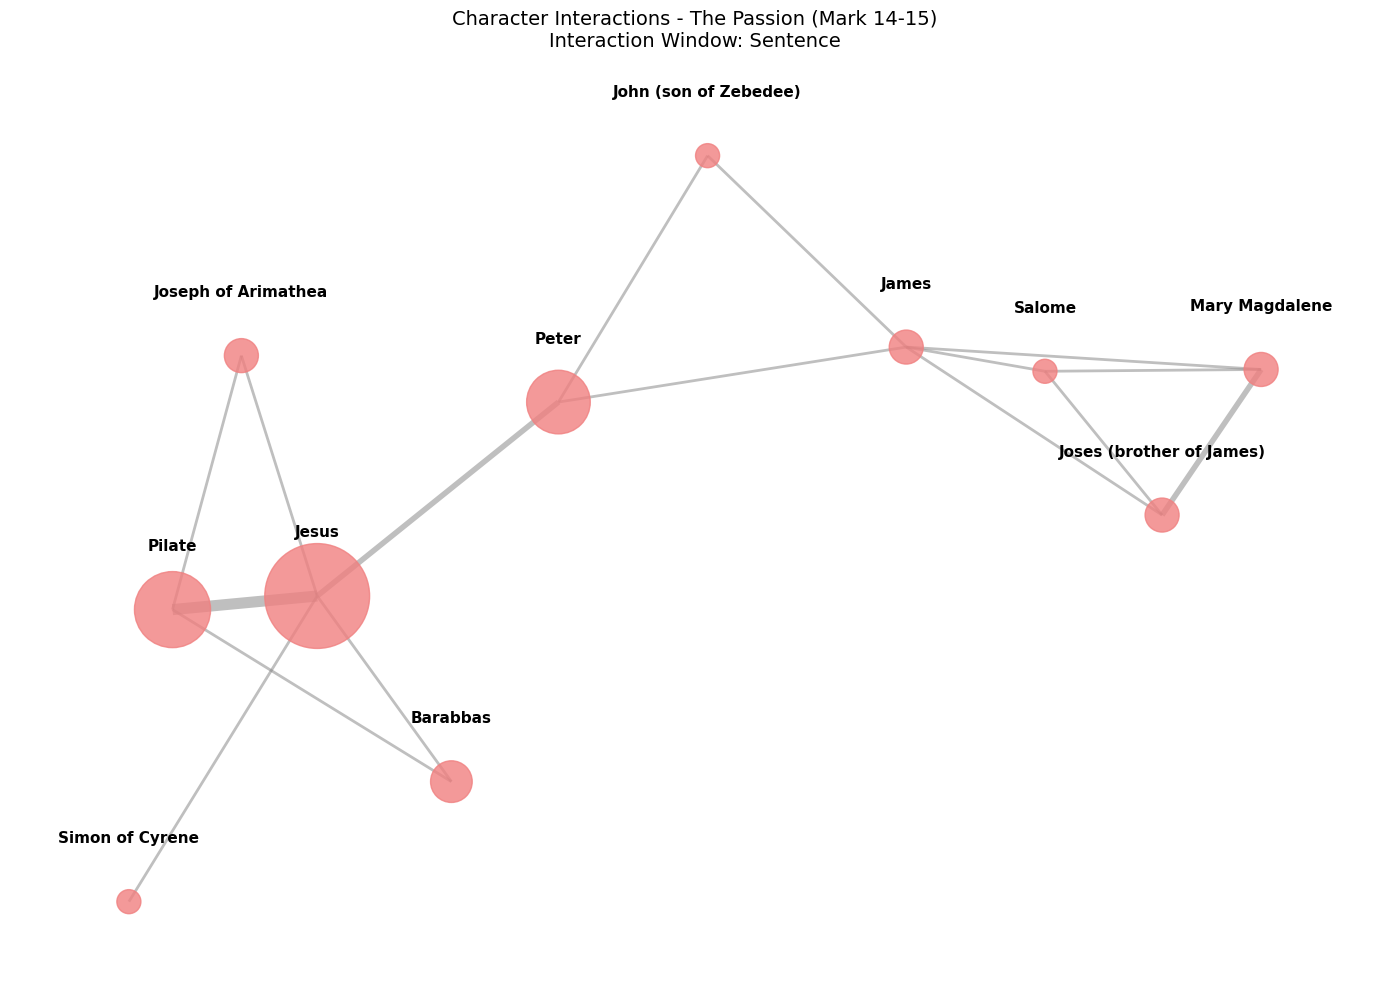

In [5]:
def plot_graph(G, title, ax):
    # Remove isolated nodes for a cleaner plot
    G = G.copy()
    G.remove_nodes_from(list(nx.isolates(G)))
    
    if G.number_of_nodes() == 0:
        ax.set_title(title + "\n(No interactions found)")
        ax.axis('off')
        return

    pos = nx.spring_layout(G, k=1.5, seed=100, iterations=100)
    
    # Node sizes based on frequency
    node_sizes = [G.nodes[n]['count'] * 300 for n in G.nodes()]
    
    # Edge widths based on weight
    edge_widths = [G[u][v]['weight'] * 2 for u, v in G.edges()]
    
    nx.draw_networkx_nodes(G, pos, ax=ax, node_color='lightcoral', 
                           node_size=node_sizes, alpha=0.8)
    nx.draw_networkx_edges(G, pos, ax=ax, width=edge_widths, 
                           edge_color='gray', alpha=0.5)
    
    # Adjust label positions slightly above the nodes
    label_pos = {k: [v[0], v[1] + 0.12] for k, v in pos.items()}
    nx.draw_networkx_labels(G, label_pos, ax=ax, font_size=11, font_weight="bold")
    
    ax.set_title(title, fontsize=14)
    ax.axis('off')

# Plot the graph
fig, ax = plt.subplots(figsize=(14, 10))
plot_graph(G_combined, "Character Interactions - The Passion (Mark 14-15)\nInteraction Window: Sentence\n", ax)
plt.tight_layout()
plt.show()


### Conclusion sur l'implémentation

1. **Pertinence narrative :** En utilisant la **phrase (sentence)** comme unité de base, le graphe capture les interactions réelles d'une même action. La modélisation est systématiquement plus pertinente narrativement que si elle s'appuyait sur les versets traditionnels (qui sont sujets aux enjambements et aux regroupements arbitraires).
2. **Le Rôle de Text-Fabric :** En permettant d'accéder instantanément à l'objet `sentence` (qui peut croiser les limites d'un `verse`) encodé par des linguistes, Text-Fabric nous libère des contraintes et des risques liés à l'utilisation d'expressions régulières sur de la ponctuation grecque classique (le point en haut `·`, le point d'interrogation `;`, etc.). L'approche continue (`odyCy`) nécessiterait un pré-traitement syntaxique complexe pour atteindre cette précision structurelle.
